# QC check 2, stage 2: secondary QC from regional statistics

Stage 1 (`qc_RR_regional_stats.ipynb`) computed, for every located station-day,
the count / median / MAD of its neighbours' rainfall at 20 km and 50 km, drawn
from the station-days that **passed QC check 1**. This notebook uses those
regional statistics to build a *secondary* QC test for the station-days that
**failed QC check 1**.

Two gradient-boosted models are trained on the reliable (QC1-pass) rows:

* **Model 1** predicts a station's own consensus rainfall from its regional
  statistics (`log1p` target, so the fit is on a stabilised scale).
* **Model 2** predicts the *absolute error* of model 1 from the same features,
  giving a per-row expected uncertainty.

A multiplier `k` is calibrated on a held-out pass split so that
`coverage_target` (default 99%) of reliable rows fall inside
`pred ± k · predicted_error`. That interval becomes the **expectation range**.
For each QC1-fail row we then check whether its transcribed consensus lands
inside the range: inside → `pass`, outside → `fail`, no usable neighbours →
`indeterminate`.

The heavy lifting lives in `src/rainfall_rescue_sqlite/parquet_secondary_qc.py`;
here we exercise it on a small demo slice and document the SLURM run.

In [1]:
# Setup roots and imports.

import os
from pathlib import Path

import numpy as np
import pandas as pd

from src.rainfall_rescue_sqlite.parquet_qc_exact_monthly import default_qc_parquet_root
from src.rainfall_rescue_sqlite.parquet_regional_stats import default_regional_stats_parquet_root
from src.rainfall_rescue_sqlite.parquet_secondary_qc import (
    FEATURE_COLUMNS,
    TARGET_COLUMN,
    build_training_frame,
    train_models,
    load_models,
    score_secondary_qc,
    default_secondary_qc_parquet_root,
)

# Cap DuckDB memory and give it a disk spill dir so the local run cannot OOM the
# workstation (the training-frame scan spills instead of crashing).
os.environ.setdefault("PDIR", "/data/scratch/philip.brohan/ADRQ")
os.environ.setdefault("DUCKDB_MEMORY_LIMIT", "3GB")
os.environ.setdefault("DUCKDB_TEMP_DIR", "/var/tmp/duckdb_secondary_qc")
Path(os.environ["DUCKDB_TEMP_DIR"]).mkdir(parents=True, exist_ok=True)

pdir = Path(os.environ["PDIR"])
qc_root = default_qc_parquet_root()
regional_root = default_regional_stats_parquet_root()
secondary_qc_root = default_secondary_qc_parquet_root()

print(f"PDIR:              {pdir}")
print(f"QC root:           {qc_root}")
print(f"regional root:     {regional_root}")
print(f"secondary-QC root: {secondary_qc_root}")
print(f"features:          {FEATURE_COLUMNS}")
print(f"target:            {TARGET_COLUMN}")

PDIR:              /data/scratch/philip.brohan/ADRQ
QC root:           /data/scratch/philip.brohan/ADRQ/qc_parquet
regional root:     /data/scratch/philip.brohan/ADRQ/regional_stats_parquet
secondary-QC root: /data/scratch/philip.brohan/ADRQ/secondary_qc_parquet
features:          ['n_20km', 'median_20km', 'mad_20km', 'n_50km', 'median_50km', 'mad_50km', 'month']
target:            consensus_value


## Build a demo training frame

`build_training_frame` joins the regional-stats table to `daily_qc_status`,
keeps the `final_flag = 'pass'` rows that have at least one 50 km neighbour and a
non-null consensus, and (when `max_rows` is set) draws a uniform — hence
month-stratified — random subsample. The SLURM job uses
`SECONDARY_MAX_TRAIN_ROWS = 5,000,000`; here we take a much smaller slice so the
notebook runs quickly on the workstation.

In [2]:
frame = build_training_frame(
    regional_root=regional_root,
    qc_root=qc_root,
    max_rows=200_000,
    seed=0,
)
print(f"training frame: {len(frame):,} rows x {frame.shape[1]} cols")
frame.describe()

training frame: 200,133 rows x 8 cols


,n_20km,median_20km,mad_20km,n_50km,median_50km,mad_50km,month,consensus_value
count,200133.000000,198474.000000,198474.000000,200133.000000,200133.000000,200133.000000,200133.000000,200133.000000
mean,26.649013,0.076216,0.017249,114.805409,0.069660,0.026526,6.053729,0.082140
std,34.299597,0.164482,0.040092,105.929528,0.144879,0.049745,3.439590,0.187328
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,0.000000,0.000000,48.000000,0.000000,0.000000,3.000000,0.000000
50%,16.000000,0.000000,0.000000,84.000000,0.000000,0.000000,6.000000,0.000000
75%,29.000000,0.080000,0.020000,144.000000,0.070000,0.035000,9.000000,0.080000
max,371.000000,3.980000,1.450000,812.000000,3.530000,1.320000,12.000000,10.110000


## Train models 1 & 2 and calibrate the range

`train_models` splits off a calibration fraction, fits model 1 on the training
split, derives honest (out-of-fold, k-fold) absolute residuals as model 2's
target, fits model 2, then picks `k` as the `coverage_target` quantile of the
per-row `residual / predicted_error` on the calibration split. The fitted models
and metadata are persisted under `secondary_qc_root/models/train_XXXXXX/`.

In [3]:
train_result = train_models(
    frame=frame,
    secondary_qc_root=secondary_qc_root,
    qc_session_id=2,  # the current daily_qc_status session
    coverage_target=0.99,
    seed=0,
    n_jobs=-1,
)
train_result

SecondaryQCTrainResult(train_session_id=1, qc_session_id=2, n_train=160106, n_calib=40027, k=8.267428847109487, coverage_target=0.99, coverage_achieved=0.9899817623104404, mae_inches=0.03447022935374915, r2_transformed=0.7471382430205731, models_dir=PosixPath('/data/scratch/philip.brohan/ADRQ/secondary_qc_parquet/models/train_000001'))

## Diagnostics

Reload the persisted models and look at how well model 1 reconstructs the
consensus, the residual distribution, and which regional features drive the
prediction (the neighbour medians should dominate). These predictions are
in-sample on the demo frame, so they are optimistic — the calibration metrics in
`train_result` (held-out) are the honest numbers.

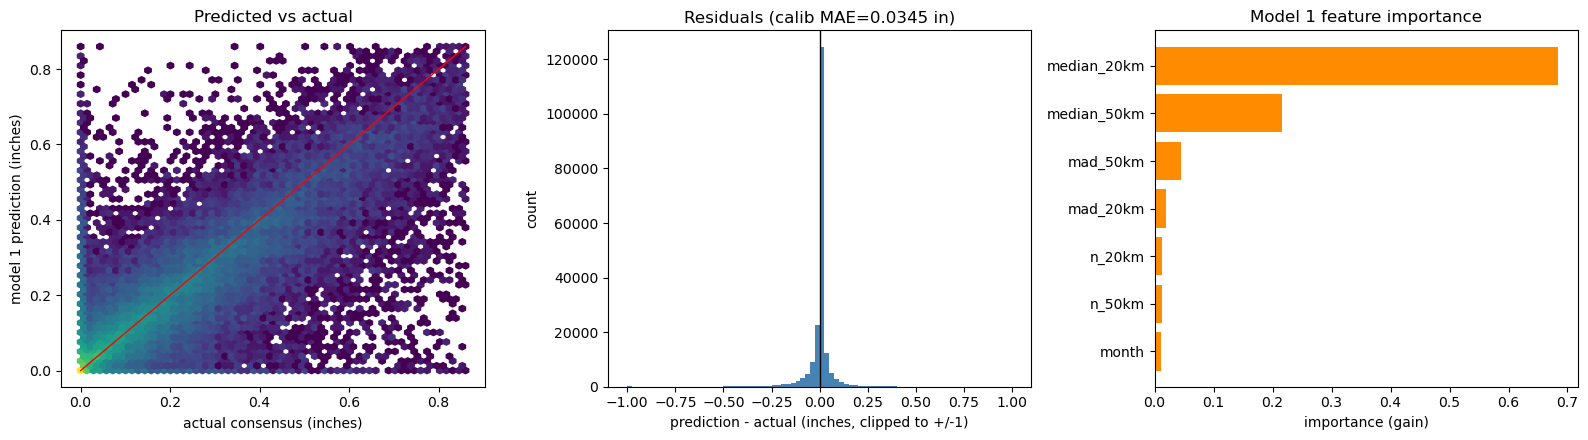

In [4]:
import matplotlib.pyplot as plt

model1, model2, meta = load_models(secondary_qc_root, train_result.train_session_id)

X = frame[FEATURE_COLUMNS].to_numpy(dtype=np.float64)
actual = frame[TARGET_COLUMN].to_numpy(dtype=np.float64)
z_pred = model1.predict(X)
pred_inches = np.expm1(z_pred)
resid_inches = pred_inches - actual

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Predicted vs actual consensus (inches).
hi = float(np.nanpercentile(actual, 99))
axes[0].hexbin(actual, pred_inches, gridsize=60, extent=(0, hi, 0, hi), cmap="viridis", bins="log")
axes[0].plot([0, hi], [0, hi], "r-", lw=1)
axes[0].set_xlabel("actual consensus (inches)")
axes[0].set_ylabel("model 1 prediction (inches)")
axes[0].set_title("Predicted vs actual")

# Residual distribution (inches).
axes[1].hist(np.clip(resid_inches, -1.0, 1.0), bins=80, color="steelblue")
axes[1].axvline(0.0, color="k", lw=1)
axes[1].set_xlabel("prediction - actual (inches, clipped to +/-1)")
axes[1].set_ylabel("count")
axes[1].set_title(f"Residuals (calib MAE={train_result.mae_inches:.4f} in)")

# Model 1 feature importances.
order = np.argsort(model1.feature_importances_)
axes[2].barh(np.array(FEATURE_COLUMNS)[order], model1.feature_importances_[order], color="darkorange")
axes[2].set_xlabel("importance (gain)")
axes[2].set_title("Model 1 feature importance")

fig.tight_layout()
plt.show()

## Coverage vs. the range multiplier `k`

`k` trades interval width against coverage. The curve below shows the fraction of
demo rows that fall inside `pred ± k · predicted_error` as `k` grows; the vertical
line is the calibrated `k` that hits the target coverage on the held-out split.

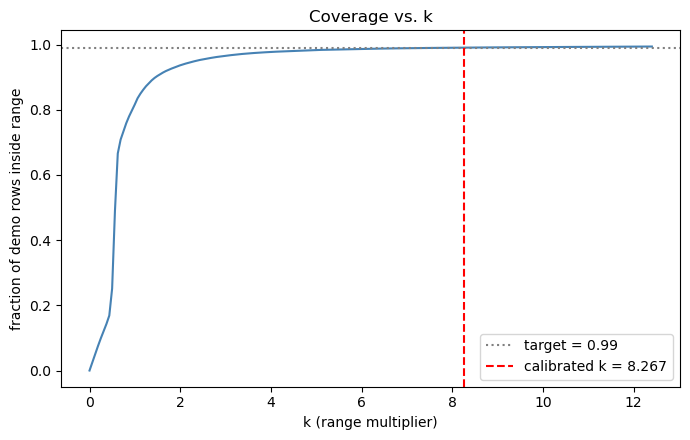

In [5]:
err_z = np.clip(model2.predict(X), 1e-6, None)
resid_z = np.abs(np.log1p(actual) - z_pred)
ratio = resid_z / err_z

k_grid = np.linspace(0.0, max(meta["k"] * 1.5, 10.0), 200)
coverage = [(ratio <= k).mean() for k in k_grid]

plt.figure(figsize=(7, 4.5))
plt.plot(k_grid, coverage, color="steelblue")
plt.axhline(meta["coverage_target"], color="grey", ls=":", label=f"target = {meta['coverage_target']:.2f}")
plt.axvline(meta["k"], color="red", ls="--", label=f"calibrated k = {meta['k']:.3f}")
plt.xlabel("k (range multiplier)")
plt.ylabel("fraction of demo rows inside range")
plt.title("Coverage vs. k")
plt.legend()
plt.tight_layout()
plt.show()

## Score a demo slice of the QC1-fail rows and hand-verify

`score_secondary_qc` streams the `final_flag = 'fail'` rows, applies both models,
builds the expectation range and writes a flag per row. We score a small
`file_id` range here and manually confirm the flag logic on a flagged row.

In [6]:
demo_score_path = secondary_qc_root / "secondary_qc_status" / "demo_slice.parquet"
score_result = score_secondary_qc(
    output_path=demo_score_path,
    regional_root=regional_root,
    qc_root=qc_root,
    secondary_qc_root=secondary_qc_root,
    train_session_id=train_result.train_session_id,
    end_file_id=20_000,
)
score_result

SecondaryQCScoreResult(train_session_id=1, qc_session_id=2, rows_written=2145448, pass_rows=2011393, fail_rows=98188, indeterminate_rows=35867, output_path=PosixPath('/data/scratch/philip.brohan/ADRQ/secondary_qc_parquet/secondary_qc_status/demo_slice.parquet'))

In [7]:
scored = pd.read_parquet(demo_score_path)
print(scored["secondary_flag"].value_counts())

flagged = scored[scored["secondary_flag"] == "fail"].head(10)
flagged[[
    "file_id", "matched_year", "month", "day_of_month",
    "consensus_value", "expectation_lower", "predicted_consensus", "expectation_upper",
]]

secondary_flag
pass             2011393
fail               98188
indeterminate      35867
Name: count, dtype: int64


,file_id,matched_year,month,day_of_month,consensus_value,expectation_lower,predicted_consensus,expectation_upper
62,1091,1911,6,1,0.66,-0.048204,0.003505,0.058024
141,1098,1918,2,18,0.29,-0.138212,0.028522,0.227515
252,1098,1918,8,5,0.00,0.107326,1.173077,3.264566
272,1098,1918,8,25,0.00,0.094587,0.916959,2.357184
314,1098,1918,10,5,0.00,0.137643,1.463018,4.332479
315,1098,1918,10,6,0.15,0.288089,1.030735,2.201552
322,1098,1918,10,13,4.55,-0.430452,0.484631,2.869967
329,1098,1918,10,20,0.80,-0.059822,0.004152,0.072481
340,1098,1918,10,31,1.55,-0.312858,0.193493,1.072973
354,1098,1918,12,14,2.63,-0.220816,0.046874,0.406529


In [8]:
# Hand-verify the flag on the first flagged row: its transcribed consensus should
# lie strictly outside [expectation_lower, expectation_upper].
row = flagged.iloc[0]
inside = row.expectation_lower <= row.consensus_value <= row.expectation_upper
print(f"file_id={int(row.file_id)}  year={int(row.matched_year)}  {int(row.month):02d}-{int(row.day_of_month):02d}")
print(f"  transcribed consensus : {row.consensus_value:.3f} in")
print(f"  expectation range     : [{row.expectation_lower:.3f}, {row.expectation_upper:.3f}] in")
print(f"  model 1 prediction    : {row.predicted_consensus:.3f} in")
print(f"  inside range?         : {inside}  (flag = {row.secondary_flag!r})")
assert not inside, "a 'fail' row must fall outside its expectation range"
print("OK: flag logic verified")

file_id=1091  year=1911  06-01
  transcribed consensus : 0.660 in
  expectation range     : [-0.048, 0.058] in
  model 1 prediction    : 0.004 in
  inside range?         : False  (flag = 'fail')
OK: flag logic verified


## Running at scale on SLURM

The full run trains on a 5-million-row month-stratified sample of the QC1-pass
rows and scores every QC1-fail row. It is two dependent single-node jobs
(`train` → `score`) driven by `scripts/slurm/submit_secondary_qc.sh`. Sizing and
roots live in `scripts/slurm/config.sh` under the `SECONDARY_QC_*` section.

```bash
# Prerequisites: QC check 1 (daily_qc_status) and QC check 2 stage 1
# (regional-stats table) must already exist.
export PDIR=/data/scratch/philip.brohan/ADRQ

# Submit train (fit + calibrate) then score (flag the fail rows) after it succeeds.
scripts/slurm/submit_secondary_qc.sh

# Override defaults inline, e.g. a larger sample or a tighter coverage target:
SECONDARY_MAX_TRAIN_ROWS=10000000 SECONDARY_COVERAGE_TARGET=0.995 \
    scripts/slurm/submit_secondary_qc.sh
```

Models land in `secondary_qc_root/models/train_XXXXXX/` and the scored flags in
`secondary_qc_root/secondary_qc_status/secondary_qc_status.parquet`.

In [10]:
# Inspect the full-scale scored output once the SLURM score job has run.
status_path = secondary_qc_root / "secondary_qc_status" / "secondary_qc_status.parquet"
if status_path.exists():
    full = pd.read_parquet(status_path, columns=["secondary_flag"])
    counts = full["secondary_flag"].value_counts()
    testable = counts.get("pass", 0) + counts.get("fail", 0)
    suspect_rate = counts.get("fail", 0) / testable if testable else float("nan")
    print(counts)
    print(f"\nsuspect rate among testable fail rows: {suspect_rate:.3%}")
else:
    print(f"No full-scale output yet at:\n  {status_path}")
    print("Run scripts/slurm/submit_secondary_qc.sh first.")

secondary_flag
pass             59536953
fail              2827638
indeterminate     1182650
Name: count, dtype: int64

suspect rate among testable fail rows: 4.534%


## Interactive secondary-QC status map

This mirrors the interactive QC-flag map in the monthly-consistency notebook, but
colours the scored (QC1-fail) stations by their `secondary_flag` for a selected
date: `pass` (consensus inside the predicted expectation range), `fail` (outside
it — a QC suspect), or `indeterminate` (no neighbours / no consensus to test).

Hovering shows the transcribed consensus and the predicted range; clicking a
station copies its specifier to the clipboard. Change `target_date` (and, if you
have several training sessions, `train_session_id`) to explore other days.


In [11]:
# Demonstrate the interactive secondary-QC status map, rendered inline.

import importlib.util
import sys
from datetime import date

from IPython.display import display
import src.rainfall_rescue_sqlite as _pkg

from src.rainfall_rescue_sqlite.parquet_similarity import default_comparison_parquet_root

repo_root = Path(_pkg.__file__).resolve().parents[2]
secondary_qc_map_script_path = repo_root / "scripts" / "diagnostics" / "plot_secondary_qc_interactive.py"

spec_sqc_map = importlib.util.spec_from_file_location(
    "secondary_qc_map_plot", secondary_qc_map_script_path
)
if spec_sqc_map is None or spec_sqc_map.loader is None:
    raise ImportError(f"Unable to load module from {secondary_qc_map_script_path}")

secondary_qc_map_plot = importlib.util.module_from_spec(spec_sqc_map)
sys.modules[spec_sqc_map.name] = secondary_qc_map_plot
spec_sqc_map.loader.exec_module(secondary_qc_map_plot)

comparison_root = default_comparison_parquet_root()
target_date = date(1911, 6, 1)
secondary_qc_map_output_path = (
    secondary_qc_root / "diagnostics" / f"secondary_qc_map_{target_date.isoformat()}.html"
)

interactive_secondary_qc_fig = secondary_qc_map_plot.build_figure(
    target_date=target_date,
    comparison_root=comparison_root,
    secondary_qc_root=secondary_qc_root,
    train_session_id=None,
    output_path=secondary_qc_map_output_path,
)

display(interactive_secondary_qc_fig)
print(f"Saved interactive HTML with click-to-copy UI: {secondary_qc_map_output_path}")


Saved interactive HTML with click-to-copy UI: /data/scratch/philip.brohan/ADRQ/secondary_qc_parquet/diagnostics/secondary_qc_map_1911-06-01.html
